In [186]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [187]:
# Download Data
data_root = "https://github.com/ageron/data/raw/main/"
lifesat = pd.read_csv(data_root + "lifesat/lifesat.csv")

In [188]:
# Prepare Data
# display(lifesat)
X = lifesat[['GDP per capita (USD)']]
Y = lifesat[['Life satisfaction']]

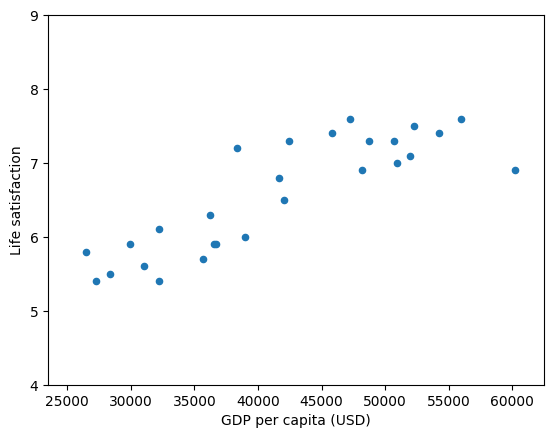

In [189]:
# Visualize data
lifesat.plot(kind = 'scatter', grid= False, x = 'GDP per capita (USD)', y = 'Life satisfaction')
plt.axis([23_500, 62_500, 4, 9])
plt.show()

In [190]:
#  two-step approach (find max, then filter by equality) works, 
# but has one subtlety — comparing floats with == can be risky if there's any floating-point rounding involved elsewhere. 

maxVal = lifesat['GDP per capita (USD)'].max()
lifesat.loc[lifesat['GDP per capita (USD)'] == maxVal]

# A more idiomatic one-liner that avoids that:
# idxmax() directly returns the index label of the row with the max value, 
# so you skip the equality comparison entirely.

lifesat.loc[lifesat['GDP per capita (USD)'].idxmax()]



Country                 United States
GDP per capita (USD)     60235.728492
Life satisfaction                 6.9
Name: 26, dtype: object

In [191]:
# Select a linear model
model = LinearRegression()

# Train the model
model.fit(X,Y)

# Analysis of Model
model.score(X,Y)

0.7272610933272652

c:\Users\kisho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


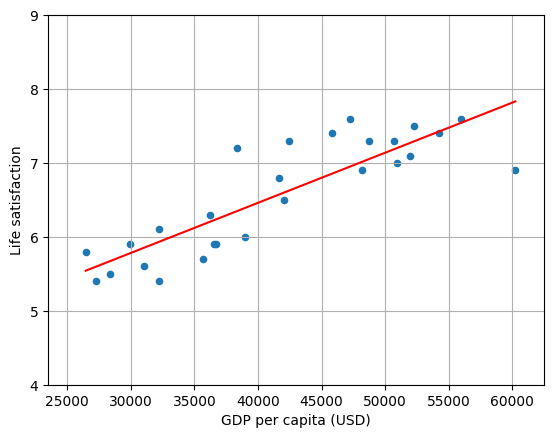

In [192]:
#Visualization

lifesat.plot(kind='scatter', grid=True, x='GDP per capita (USD)', y='Life satisfaction')

X = np.sort(lifesat[['GDP per capita (USD)']], axis= 0)
y_line = model.predict(X)

plt.plot(X, y_line, color='red')
plt.axis([23_500, 62_500, 4, 9])
plt.show()


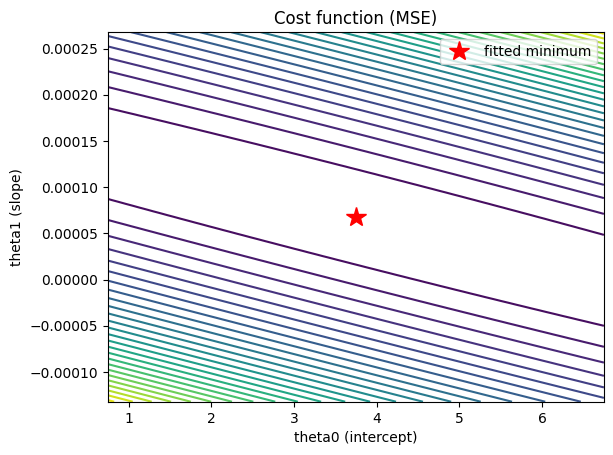

In [193]:
# Contour Graph

X_vals = lifesat['GDP per capita (USD)'].values
y_vals = lifesat['Life satisfaction'].values

theta0_range = np.linspace(model.intercept_ - 3, model.intercept_ + 3, 100)
theta1_range = np.linspace(model.coef_[0] - 0.0002, model.coef_[0] + 0.0002, 100)
T0, T1 = np.meshgrid(theta0_range, theta1_range)

cost = np.zeros(T0.shape)
for i in range(T0.shape[0]):
    for j in range(T0.shape[1]):
        preds = T0[i, j] + T1[i, j] * X_vals
        cost[i, j] = np.mean((preds - y_vals) ** 2)

plt.contour(T0, T1, cost, levels=30, cmap='viridis')
plt.plot(model.intercept_, model.coef_[0], 'r*', markersize=15, label='fitted minimum')
plt.xlabel('theta0 (intercept)')
plt.ylabel('theta1 (slope)')
plt.title('Cost function (MSE)')
plt.legend()
plt.show()


In [194]:
# Range & Slope

y_range = lifesat['Life satisfaction'].max() - lifesat['Life satisfaction'].min()
x_range = lifesat['GDP per capita (USD)'].max() - lifesat['GDP per capita (USD)'].min()
print(y_range / x_range)

6.512856568385047e-05


In [195]:
print(model.intercept_)
print(model.coef_)

[3.74904943]
[[6.77889969e-05]]


In [196]:
# Make a prediction for Puerto Rico
X_New = [[33_442.8]]
print(model.predict(X_New))

[[6.01610329]]


c:\Users\kisho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [197]:
# Scaled Features

gdp_mean = lifesat['GDP per capita (USD)'].mean()
gdp_std = lifesat['GDP per capita (USD)'].std()
X_scaled = (lifesat[['GDP per capita (USD)']] - gdp_mean) / gdp_std

y_mean = lifesat['Life satisfaction'].mean()
y_std = lifesat['Life satisfaction'].std()
y_scaled = (lifesat['Life satisfaction'] - y_mean) / y_std


In [198]:
model.fit(X_scaled, y_scaled)
print(model.score(X_scaled, y_scaled))

0.7272610933272652


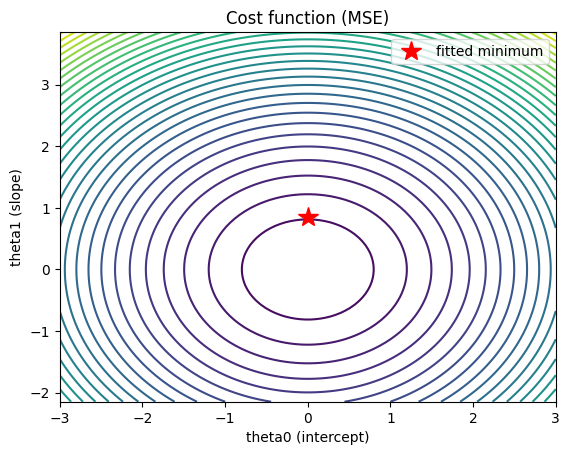

In [199]:
X_vals = np.array(X_scaled)
y_vals = np.array(y_scaled)

theta0_range = np.linspace(model.intercept_ - 3, model.intercept_ + 3, 100)
theta1_range = np.linspace(model.coef_[0] - 3, model.coef_[0] + 3, 100)

T0, T1 = np.meshgrid(theta0_range, theta1_range)

cost = np.zeros(T0.shape)
for i in range(T0.shape[0]):
    for j in range(T0.shape[1]):
        preds = T0[i, j] + T1[i, j] * X_vals
        cost[i, j] = np.mean((preds - y_vals) ** 2)

plt.contour(T0, T1, cost, levels=30, cmap='viridis')
plt.plot(model.intercept_, model.coef_[0], 'r*', markersize=15, label='fitted minimum')
plt.xlabel('theta0 (intercept)')
plt.ylabel('theta1 (slope)')
plt.title('Cost function (MSE)')
plt.legend()
plt.show()

In [200]:
print(y_scaled.mean())
print(model.intercept_)

3.310109388234263e-16
7.86874622130232e-16


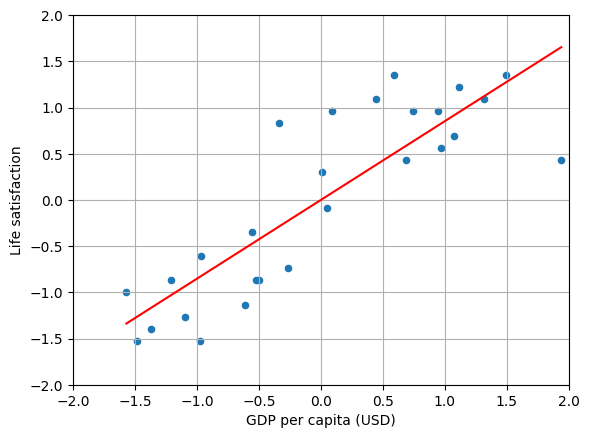

In [201]:
#Visualization

y_scaled_line = model.predict(X_scaled)

plotDF = pd.concat([pd.DataFrame(X_scaled), pd.DataFrame(y_scaled, columns= ["Life satisfaction"])], axis=1)
plotDF.plot(kind='scatter', grid=True, x='GDP per capita (USD)', y='Life satisfaction')
plt.plot(X_scaled, y_scaled_line, color='red')
plt.axis([-2, 2, -2, 2])
plt.show()

In [202]:
# Make a prediction for Puerto Rico
X_Scaled_New = [[(33_442.8 - gdp_mean)/ gdp_std ]]
print(model.predict(X_New))

[28519.88755333]


c:\Users\kisho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [203]:
mae = mean_absolute_error(y_scaled, y_scaled_line)
mse = mean_squared_error(y_scaled, y_scaled_line)
rmse = np.sqrt(mse)          # version-safe way to get RMSE
r2 = r2_score(y_scaled, y_scaled_line)

print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}")

MAE:  0.4082
MSE:  0.2626
RMSE: 0.5125
R2:   0.7273


In [ ]:
# Remove Value which looks out of trend for analysis purpose
# Remove US and check

o_data = lifesat.drop(lifesat["GDP per capita (USD)"].idxmax())

O_X = o_data[['GDP per capita (USD)']]
O_Y = o_data[['Life satisfaction']]

In [205]:
O_X_Scaled = (O_X - O_X.mean()) / O_X.std()
O_Y_Scaled = (O_Y - O_Y.mean()) / O_Y.std()

In [206]:
model.fit(O_X_Scaled, O_Y_Scaled)
model.score(O_X_Scaled, O_Y_Scaled)

0.7954089069638666

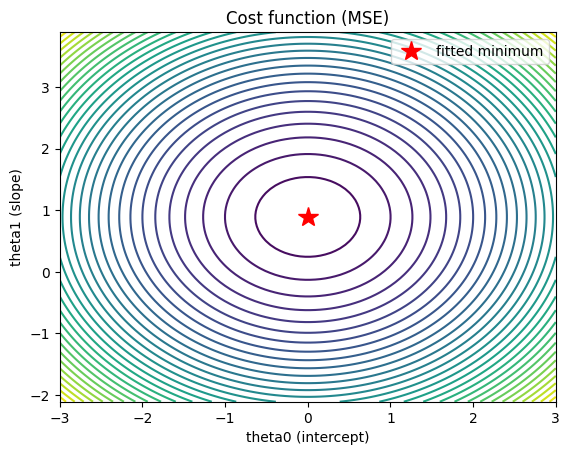

In [207]:
X_vals = np.array(O_X_Scaled)
y_vals = np.array(O_Y_Scaled)

theta0_range = np.linspace(model.intercept_ - 3, model.intercept_ + 3, 100)
theta1_range = np.linspace(model.coef_[0] - 3, model.coef_[0] + 3, 100)

T0, T1 = np.meshgrid(theta0_range, theta1_range)

cost = np.zeros(T0.shape)
for i in range(T0.shape[0]):
    for j in range(T0.shape[1]):
        preds = T0[i, j] + T1[i, j] * X_vals
        cost[i, j] = np.mean((preds - y_vals) ** 2)

plt.contour(T0, T1, cost, levels=30, cmap='viridis')
plt.plot(model.intercept_, model.coef_[0], 'r*', markersize=15, label='fitted minimum')
plt.xlabel('theta0 (intercept)')
plt.ylabel('theta1 (slope)')
plt.title('Cost function (MSE)')
plt.legend()
plt.show()

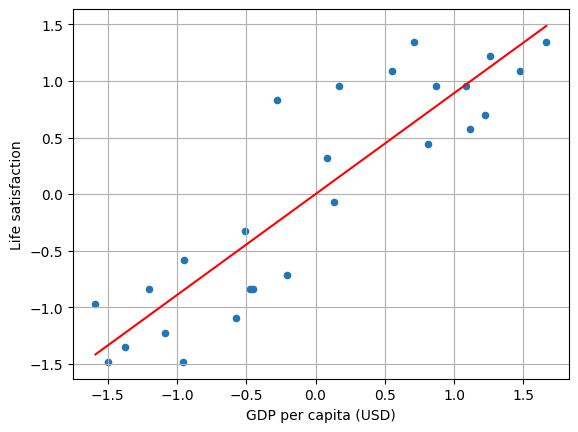

In [208]:
# Visualize

O_Data = pd.concat([pd.DataFrame(O_X_Scaled), pd.DataFrame(O_Y_Scaled)], axis= 1)
O_Data.plot(kind= 'scatter', grid= True, x='GDP per capita (USD)', y='Life satisfaction')

O_Y_Scaled_Line = model.predict(O_X_Scaled)

plt.plot(O_X_Scaled, O_Y_Scaled_Line, color = 'red')
plt.show()

In [209]:
# Make a prediction for Puerto Rico
X_Scaled_New = [[(33_442.8 - O_X.mean()) / O_X.std() ]]

print(model.predict(X_New))

[[29826.19525176]]


c:\Users\kisho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [210]:
mae = mean_absolute_error(O_Y_Scaled, O_Y_Scaled_Line)
mse = mean_squared_error(O_Y_Scaled, O_Y_Scaled_Line)
rmse = np.sqrt(mse)          # version-safe way to get RMSE
r2 = r2_score(O_Y_Scaled, O_Y_Scaled_Line)

print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}")

MAE:  0.3680
MSE:  0.1967
RMSE: 0.4435
R2:   0.7954


In [ ]:
# Polynomial Degree

from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(lifesat[['GDP per capita (USD)']])
model_poly = LinearRegression()
model_poly.fit(X_poly, Y)
print(model_poly.score(X_poly, Y))


0.7718683452775508


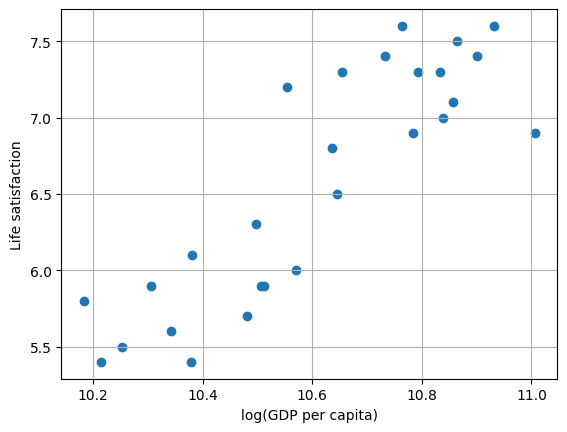

In [223]:
plt.scatter(np.log(lifesat[['GDP per capita (USD)']]), Y)
plt.xlabel('log(GDP per capita)')
plt.ylabel('Life satisfaction')
plt.grid(True)
plt.show()
